# introduction to quantum audio
Article : [Quantum Representations of Sound: from
mechanical waves to quantum circuits](https://arxiv.org/pdf/2301.01595)


# Single Qubit Probability Amplitude Modulations: SQPAM

For $N$ audio samples, with $n = \left\lceil log(N) \right\rceil + 1$ qubits, the representation of the quantum state 
$$ |A_{SQPAM}\rangle = \frac{1}{\sqrt{N}}\sum_{i=0}^{N-1}(\text{cos}(\theta_i|0\rangle + \text{sin}(\theta_i|1\rangle)\otimes|i\rangle$$

Mapping the digital amplitudes audio to SQPAM:\


Relation between $a_i$ and $\alpha_i$: 
- Step 1: Add 1 to all amplitudes $a_n$
- Step 2: divide the amplitudes by 2.
- Step 3: take the square root
- Step 4: Evaluate the Inverse Sine of the result (The Inverse Cosine is also applicable, as long as the same convention is followed throughout the implementation)

$$ \theta_i = \text{sin}^{-1}\Bigl(\sqrt{\frac{a_i+1}{2}}\Bigl) $$

The mapped array of angles will enable the preparation of the SQPAM quantum audio
state.

### Preparation of the states
Require $n$ quibts for encodng the time, and $1$ qubit for the amplitude.

In [12]:
# importation of the modules
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import RYGate
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

In [13]:
# Functions 
def getFullScaleMeasured(statistics, Nqubits):
    """
    fill the string measured with the null values measured
    Input : 
        - statistics(dict)
        - Nqubits(int)
    Output:
        - full_statistics(dict): statistics with the null values
    """
    full_statistics = {}
    for i in range(2**Nqubits):
        # Converts the integer i to binary and adds leading zeros (padding)
        bitstring = format(i, f'0{Nqubits}b')
        
        # If the flag is set, we take its value; otherwise, we set it to 0
        full_statistics[bitstring] = statistics.get(bitstring, 0)
    return full_statistics

# generation of the binary list depending of the number of qubits
def generate_binary_list_from_nqubits(n_qubits):
    """
    Generates binary strings in ascending numerical order.
    Example for 2 qubits: [‘00’, ‘01’, ‘10’, ‘11’]
    Input: 
        - n_qubits(Int) : number of qubits
    Output:
        - list of 2**n_qubits binary ascendant
    """
    return [format(i, f'0{n_qubits}b') for i in range(2**n_qubits)]


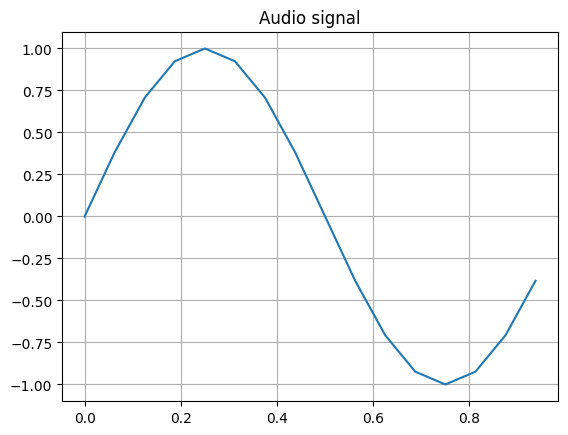

In [14]:
# Creation of an audio signal 

# audio samples
Nqubits = 4
temp = np.arange(0,2**Nqubits, 1)/2**Nqubits
amplitudes = np.sin(2*np.pi*temp)

plt.plot(temp, amplitudes)
plt.title("Audio signal")
plt.grid()

## Preparation of the state
Each time qubits are initialized with a Hadamard Gate. 

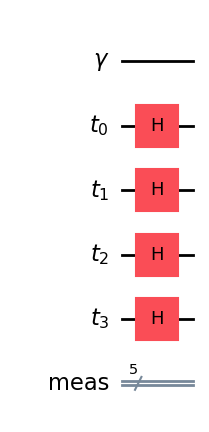

In [15]:
# Number of qubits which represents the time
timeQ = QuantumRegister(Nqubits, "t")
AmpQ = QuantumRegister(1, r"\gamma") # amplitude qubit
measure = ClassicalRegister(Nqubits+1, "meas") 

SQPAM_circuit = QuantumCircuit(AmpQ, timeQ, measure)
SQPAM_circuit.h(range(1,Nqubits+1))

display(SQPAM_circuit.draw(output="mpl"))

For each value of $\theta_i$, an $R_y(\theta_i)$ is applied, with $\gamma$ as a target and the $t_k$ time qubits as controlled qubits. 
Considering the time is indexing through the line from left to right, the index of time is indexing with binary value. 

For example, for the first sample ($\theta_0$), the time index is $00$ for 2 time qubits. for the second sample ($\theta_1$), the time index is $01$, then for the third sample ($\theta_2$), the time index is $10$, etc. 

If the corresponding binary value is $0$, then an $X$ gate is applied before and after the $R_y$ gate, according to the position of the binary value. 

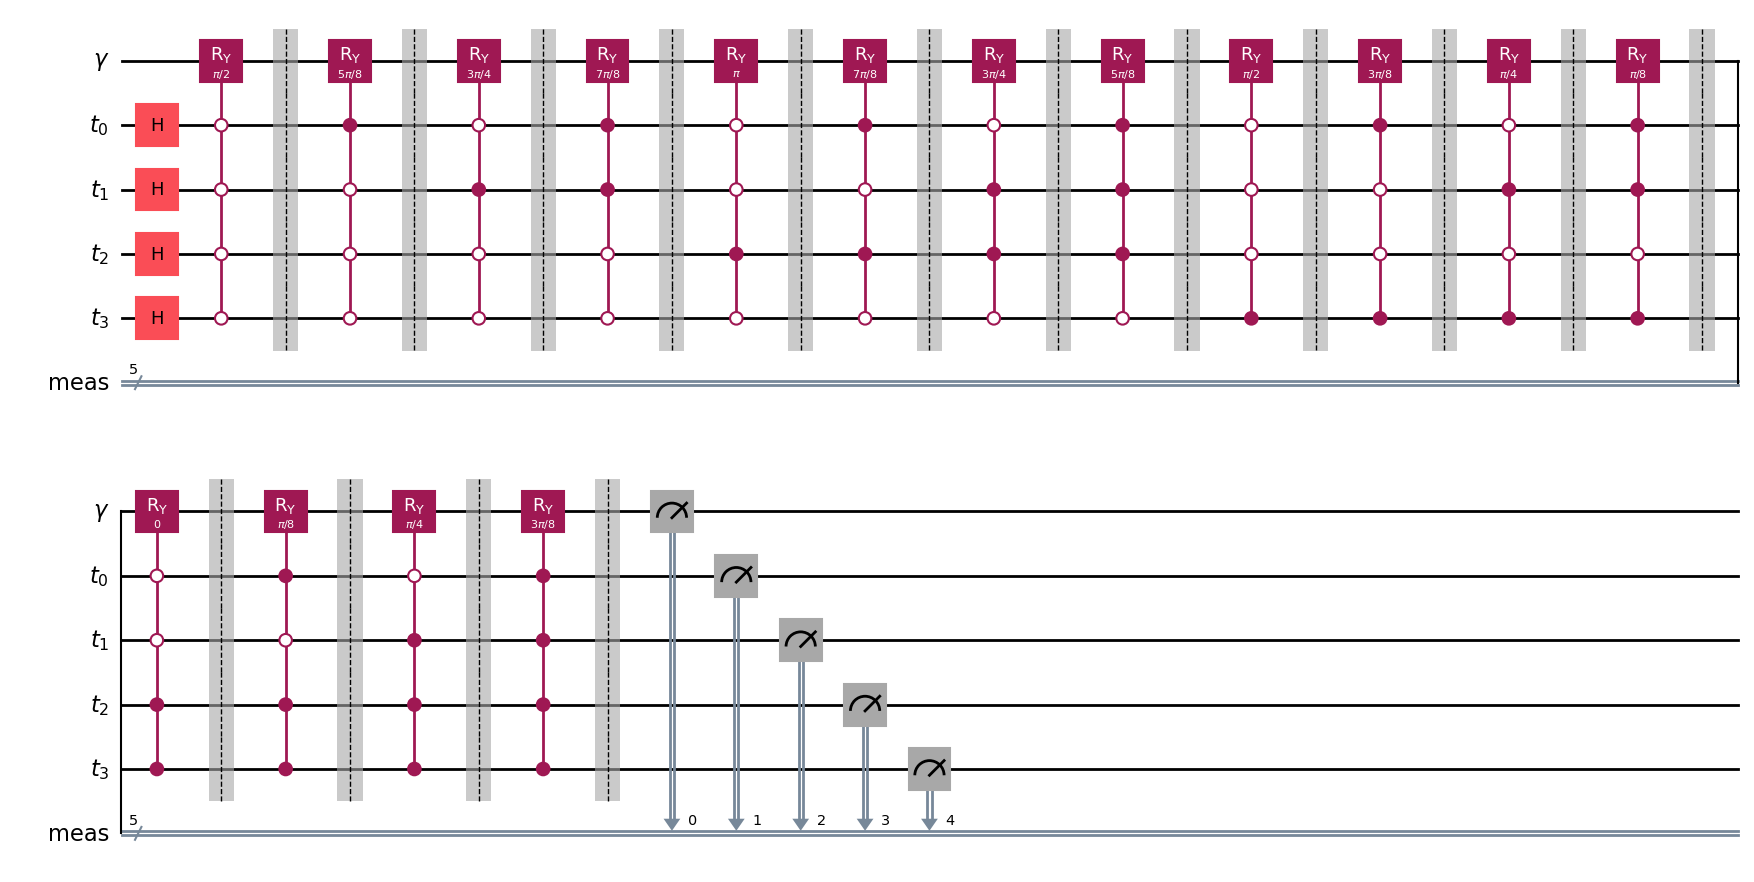

In [16]:
# Conversion of the audio samples to quantum amplitudes
theta = np.asin(np.sqrt((amplitudes+1)/2))

# Generation of the binary list
BinaryList =generate_binary_list_from_nqubits(Nqubits)


for index, binary in enumerate(BinaryList):
    # find null index in the binary string
    indices_zeros= [i+1 for i, bit in enumerate(reversed(binary)) if bit == '0']

    # apply Ry controled gate, and use of the ctrl_state to apply X gates on the binary value which is equal to 0
    theta_param = theta[index]
    cry_gate = RYGate(2*theta_param).control(Nqubits, ctrl_state=binary) #/!\ the angle to apply is twice in qiskit
    SQPAM_circuit.append(cry_gate, list(timeQ)+list(AmpQ))

    # apply X gates
    SQPAM_circuit.barrier()

SQPAM_circuit.measure(AmpQ, measure[0])
SQPAM_circuit.measure(timeQ, measure[1:Nqubits+1])
display(SQPAM_circuit.draw(output="mpl"))

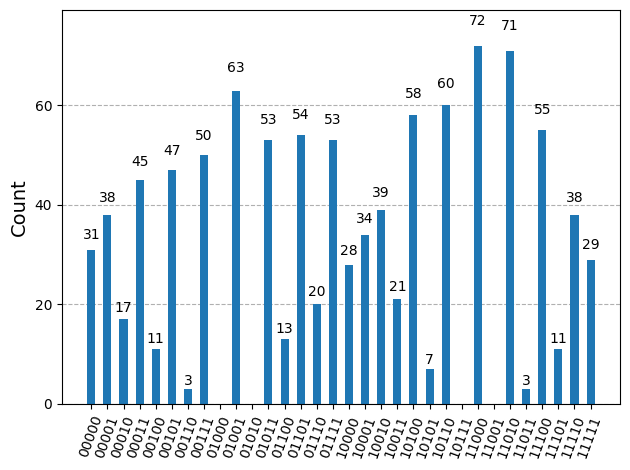

In [34]:
# run on backend then plot the histogramm
simulator = AerSimulator()
circuit_decompose = transpile(SQPAM_circuit, simulator)
stats = simulator.run(circuit_decompose).result()
statistics = stats.get_counts()

# add null measure
full_statistics = getFullScaleMeasured(statistics, Nqubits+1)
display(plot_histogram(full_statistics))

The following equation allowed to recover the original signal. 

$$ a_i = \frac{2p_{\gamma_i}(|1\rangle)}{p_{\gamma_i}(|0\rangle)+2p_{\gamma_i}(|1\rangle)}-1$$

$p_{\gamma_i}(|0\rangle)$ and $p_{\gamma_i}(|1\rangle)$  correspond to the probabilities of the $\gamma_i$ state 

In [32]:
# Separation of the results p0, p1.
counts_gamma_0 = {}
counts_gamma_1 = {}

# to order the dict
ordered_items = sorted(full_statistics.items())

for bitstring, count in ordered_items:
    value_gamma = bitstring[Nqubits]  # The last qubits correspond to the gamma value
    remain_bits = bitstring[:-1]   # The other qubits correspon to the time
    if value_gamma == '0':
        counts_gamma_0[remain_bits] = count
    else:
        counts_gamma_1[remain_bits] = count

print("Gamma = 0 :", counts_gamma_0)
print("Gamma = 1 :", counts_gamma_1)

Gamma = 0 : {'0000': 37, '0001': 19, '0010': 7, '0011': 2, '0100': 0, '0101': 4, '0110': 10, '0111': 19, '1000': 36, '1001': 51, '1010': 53, '1011': 52, '1100': 64, '1101': 56, '1110': 53, '1111': 51}
Gamma = 1 : {'0000': 45, '0001': 35, '0010': 58, '0011': 66, '0100': 72, '0101': 58, '0110': 50, '0111': 30, '1000': 28, '1001': 21, '1010': 9, '1011': 2, '1100': 0, '1101': 3, '1110': 10, '1111': 23}


## Recover the signal

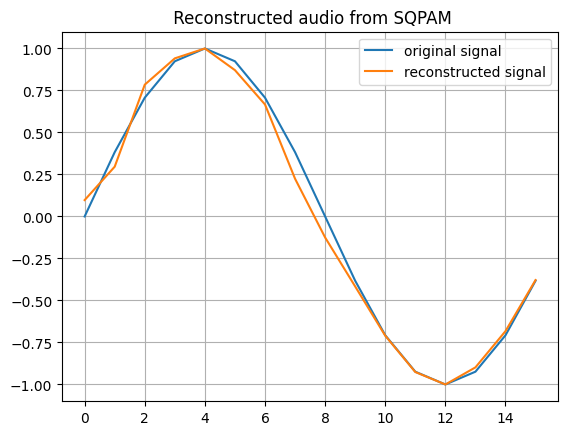

In [33]:
p0 = np.array(list(counts_gamma_0.values()))
p1 = np.array(list(counts_gamma_1.values()))

ampRec = 2*p1/(p0+p1)-1
plt.plot(amplitudes, label="original signal")
plt.plot(ampRec, label = "reconstructed signal")
plt.title(" Reconstructed audio from SQPAM")
plt.grid()
plt.legend()